## EDA Natalidad Madrid

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_indicadores = pd.read_csv("indicadores-de-natalidad-y-fecundidad.csv", sep=";", encoding="latin1")
df_indicadores.head()

,Año,Concepto,Tipo territorio,Código territorio,Territorio,Valor,Unidad,Estado dato
0,1985,Edad media de la madre al nacimiento del terce...,Otros,NaN,NaN,32.82,Años,NaN
1,1985,Edad media de la madre al nacimiento del prime...,Otros,NaN,NaN,25.74,Años,NaN
2,1985,Edad media de la madre al nacimiento del segun...,Otros,NaN,NaN,28.67,Años,NaN
3,1985,Edad media de la madre,Otros,NaN,NaN,28.61,Años,NaN
4,1985,Indice sintético de fecundidad,Otros,NaN,NaN,1.55,Índice,NaN


In [3]:
df_indicadores.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Año                520 non-null    int64  
 1   Concepto           520 non-null    str    
 2   Tipo territorio    520 non-null    str    
 3   Código territorio  0 non-null      float64
 4   Territorio         0 non-null      float64
 5   Valor              520 non-null    str    
 6   Unidad             520 non-null    str    
 7   Estado dato        0 non-null      float64
dtypes: float64(3), int64(1), str(4)
memory usage: 32.6 KB


In [4]:
df_indicadores.isnull().sum()

Año                    0
Concepto               0
Tipo territorio        0
Código territorio    520
Territorio           520
Valor                  0
Unidad                 0
Estado dato          520
dtype: int64

In [5]:
df_indicadores[pd.to_numeric(df_indicadores["Valor"], errors="coerce").isnull()]

,Año,Concepto,Tipo territorio,Código territorio,Territorio,Valor,Unidad,Estado dato
7,1985,Edad media de la madre extranjera,Otros,NaN,NaN,-,Porcentaje,NaN
8,1985,Edad media de la madre española,Otros,NaN,NaN,-,Porcentaje,NaN
19,1986,Edad media de la madre extranjera,Otros,NaN,NaN,-,Porcentaje,NaN
20,1986,Edad media de la madre española,Otros,NaN,NaN,-,Porcentaje,NaN
32,1987,Edad media de la madre española,Otros,NaN,NaN,-,Porcentaje,NaN
35,1987,Edad media de la madre extranjera,Otros,NaN,NaN,-,Porcentaje,NaN
45,1988,Edad media de la madre extranjera,Otros,NaN,NaN,-,Porcentaje,NaN
46,1988,Edad media de la madre española,Otros,NaN,NaN,-,Porcentaje,NaN
58,1989,Edad media de la madre extranjera,Otros,NaN,NaN,-,Porcentaje,NaN
62,1989,Edad media de la madre española,Otros,NaN,NaN,-,Porcentaje,NaN


In [6]:
df_indicadores["Valor"] = pd.to_numeric(df_indicadores["Valor"], errors="coerce")
df_indicadores.dtypes

Año                    int64
Concepto                 str
Tipo territorio          str
Código territorio    float64
Territorio           float64
Valor                float64
Unidad                   str
Estado dato          float64
dtype: object

In [7]:
df_indicadores["Concepto"].unique()

<StringArray>
['Edad media de la madre al nacimiento del tercer hijo y sucesivos',
             'Edad media de la madre al nacimiento del primer hijo',
            'Edad media de la madre al nacimiento del segundo hijo',
                                           'Edad media de la madre',
                                   'Indice sintético de fecundidad',
                                           'Crecimiento vegetativo',
         'Proporción de hombres nacidos respecto a mujeres nacidas',
                                'Edad media de la madre extranjera',
                                  'Edad media de la madre española',
       'Proporción de hombres nacidos respecto al total de nacidos',
                        'Proporción de nacimientos de madre casada',
                                       'Tasa general de fecundidad',
                                          'Tasa bruta de natalidad']
Length: 13, dtype: str

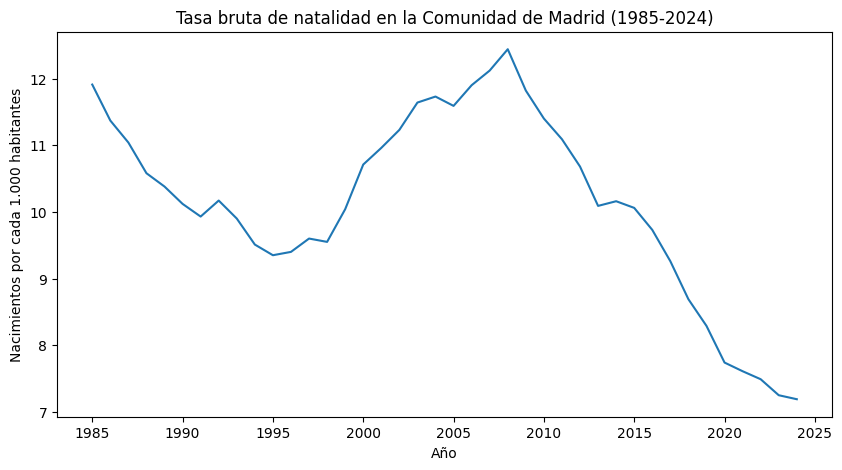

In [8]:
tasa_natalidad = df_indicadores[df_indicadores["Concepto"] == "Tasa bruta de natalidad"]

plt.figure(figsize=(10, 5))
sns.lineplot(data=tasa_natalidad, x="Año", y="Valor")
plt.title("Tasa bruta de natalidad en la Comunidad de Madrid (1985-2024)")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1.000 habitantes")
plt.show()

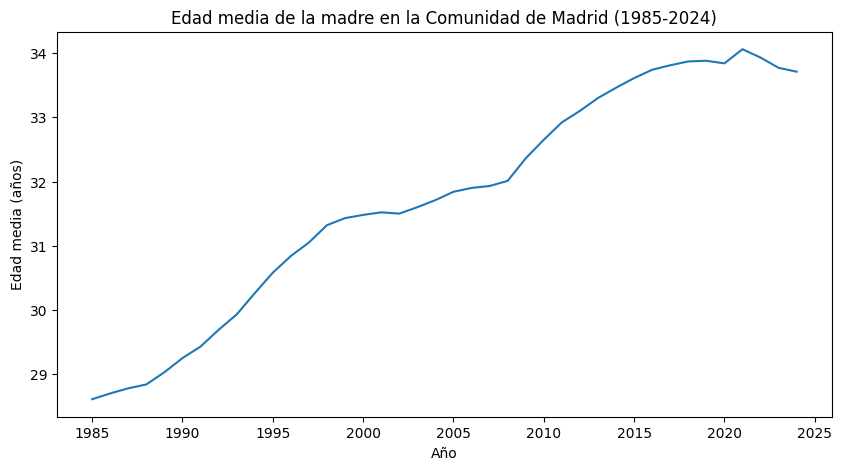

In [9]:
edad_media = df_indicadores[df_indicadores["Concepto"] == "Edad media de la madre"]

plt.figure(figsize=(10, 5))
sns.lineplot(data=edad_media, x="Año", y="Valor")
plt.title("Edad media de la madre en la Comunidad de Madrid (1985-2024)")
plt.xlabel("Año")
plt.ylabel("Edad media (años)")
plt.show()

In [10]:
df_municipios = pd.read_csv("nacidos-vivos-de-madres-residentes-por-grupo-de-edad-y-nacionalidad-de-la-madre.-municipios.csv", sep=";", encoding="latin1")
df_municipios.head()

,Año,Tipo territorio,Código territorio,Territorio,Edad,Nacionalidad,Valor,Unidad,Estado dato
0,1995,Comunidad de Madrid,NaN,Comunidad de Madrid,Total,Extranjeras,2795,Número,NaN
1,1995,Municipios,14.0,Acebeda (La),Total,Extranjeras,0,Número,NaN
2,1995,Municipios,29.0,Ajalvir,Total,Extranjeras,0,Número,NaN
3,1995,Municipios,35.0,Alameda del Valle,Total,Extranjeras,0,Número,NaN
4,1995,Municipios,40.0,Álamo (El),Total,Extranjeras,8,Número,NaN


In [11]:
df_municipios.info()

<class 'pandas.DataFrame'>
RangeIndex: 148980 entries, 0 to 148979
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Año                148980 non-null  int64  
 1   Tipo territorio    148980 non-null  str    
 2   Código territorio  148200 non-null  float64
 3   Territorio         148980 non-null  str    
 4   Edad               148980 non-null  str    
 5   Nacionalidad       148980 non-null  str    
 6   Valor              148980 non-null  int64  
 7   Unidad             148980 non-null  str    
 8   Estado dato        0 non-null       float64
dtypes: float64(2), int64(2), str(5)
memory usage: 10.2 MB


In [12]:
print(df_municipios["Tipo territorio"].unique())
print(df_municipios["Edad"].unique())
print(df_municipios["Nacionalidad"].unique())
print(df_municipios["Año"].min(), "-", df_municipios["Año"].max())

<StringArray>
['Comunidad de Madrid', 'Municipios', 'Zonas Estadísticas']
Length: 3, dtype: str
<StringArray>
[             'Total', 'Menores de 15 años',    'De 15 a 19 años',
    'De 20 a 24 años',    'De 25 a 29 años',    'De 30 a 34 años',
    'De 35 a 39 años',    'De 40 a 44 años',    'De 45 a 49 años',
   'De 50 años y más']
Length: 10, dtype: str
<StringArray>
['Extranjeras', 'Total', 'Españolas']
Length: 3, dtype: str
1993 - 2024


In [13]:
ejemplo = df_municipios[
    (df_municipios["Territorio"] == "Madrid") &
    (df_municipios["Año"] == 2024) &
    (df_municipios["Nacionalidad"] == "Total")
]
ejemplo

,Año,Tipo territorio,Código territorio,Territorio,Edad,Nacionalidad,Valor,Unidad,Estado dato
11730,2024,Municipios,796.0,Madrid,Menores de 15 años,Total,11,Número,NaN
17842,2024,Municipios,796.0,Madrid,De 15 a 19 años,Total,377,Número,NaN
23954,2024,Municipios,796.0,Madrid,De 20 a 24 años,Total,1791,Número,NaN
30066,2024,Municipios,796.0,Madrid,De 25 a 29 años,Total,4043,Número,NaN
36178,2024,Municipios,796.0,Madrid,De 30 a 34 años,Total,8576,Número,NaN
42290,2024,Municipios,796.0,Madrid,De 35 a 39 años,Total,8348,Número,NaN
48402,2024,Municipios,796.0,Madrid,De 40 a 44 años,Total,2818,Número,NaN
54514,2024,Municipios,796.0,Madrid,De 45 a 49 años,Total,336,Número,NaN
60626,2024,Municipios,796.0,Madrid,De 50 años y más,Total,40,Número,NaN


In [14]:
edad_ayuda = ["Menores de 15 años", "De 15 a 19 años", "De 20 a 24 años", "De 25 a 29 años"]

madres_jovenes_2024 = df_municipios[
    (df_municipios["Tipo territorio"] == "Municipios") &
    (df_municipios["Año"] == 2024) &
    (df_municipios["Nacionalidad"] == "Total") &
    (df_municipios["Edad"].isin(edad_ayuda))
]

top10 = madres_jovenes_2024.groupby("Territorio")["Valor"].sum().sort_values(ascending=False).head(10)
top10

Territorio
Madrid               6222
Parla                 388
Alcalá de Henares     371
Móstoles              337
Getafe                332
Leganés               297
Torrejón de Ardoz     289
Fuenlabrada           285
Alcorcón              230
Alcobendas            198
Name: Valor, dtype: int64

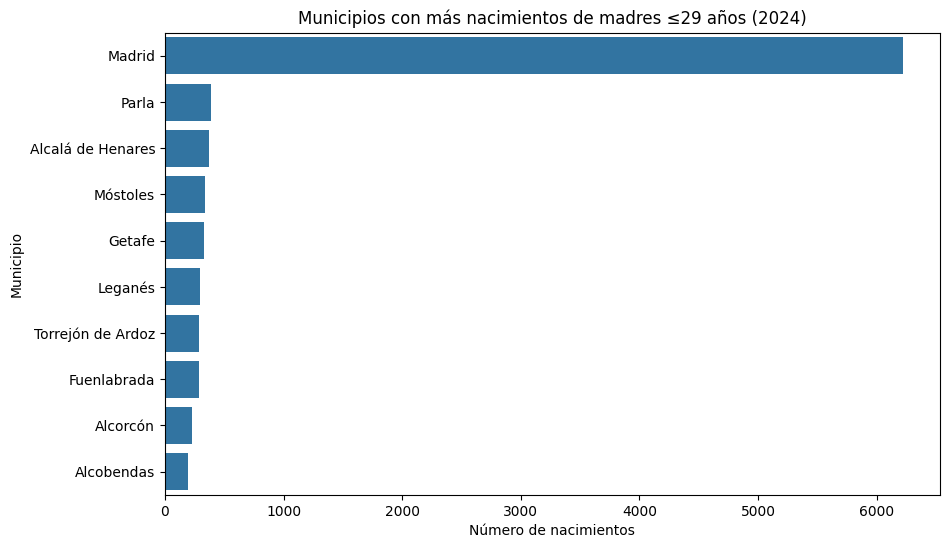

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index, orient="h")
plt.title("Municipios con más nacimientos de madres ≤29 años (2024)")
plt.xlabel("Número de nacimientos")
plt.ylabel("Municipio")
plt.show()

In [16]:
df_nacionalidad = pd.read_csv("nacidos-vivos-de-madres-residentes-por-nacionalidad-de-la-madre-total.csv", sep=";", encoding="latin1")
df_nacionalidad.head()

,Año,Concepto,Tipo territorio,Código territorio,Territorio,Valor,Unidad,Estado dato
0,1995,Nacimientos de madres residentes extranjeras d...,Otros,NaN,NaN,600,Número,NaN
1,1995,Nacimientos de madres residentes extranjeras d...,Otros,NaN,NaN,25,Número,NaN
2,1995,Nacimientos de madres residentes extranjeras d...,Otros,NaN,NaN,376,Número,NaN
3,1995,Nacimientos de madres residentes extranjeras d...,Otros,NaN,NaN,1065,Número,NaN
4,1995,Nacimientos de madres residentes no consta nac...,Otros,NaN,NaN,0,Número,NaN


In [17]:
df_nacionalidad.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Año                270 non-null    int64  
 1   Concepto           270 non-null    str    
 2   Tipo territorio    270 non-null    str    
 3   Código territorio  0 non-null      float64
 4   Territorio         0 non-null      float64
 5   Valor              270 non-null    int64  
 6   Unidad             270 non-null    str    
 7   Estado dato        0 non-null      float64
dtypes: float64(3), int64(2), str(3)
memory usage: 17.0 KB


In [18]:
df_nacionalidad["Concepto"].unique()

<StringArray>
[                       'Nacimientos de madres residentes extranjeras de África',
                 'Nacimientos de madres residentes extranjeras del resto Europa',
                          'Nacimientos de madres residentes extranjeras de Asia',
                       'Nacimientos de madres residentes extranjeras de América',
                       'Nacimientos de madres residentes no consta nacionalidad',
                                  'Nacimientos de madres residentes extranjeras',
 'Nacimientos de madres residentes extranjeras de la Unión Europea (sin España)',
                       'Nacimientos de madres residentes extranjeras de Oceanía',
                                    'Nacimientos de madres residentes españolas']
Length: 9, dtype: str

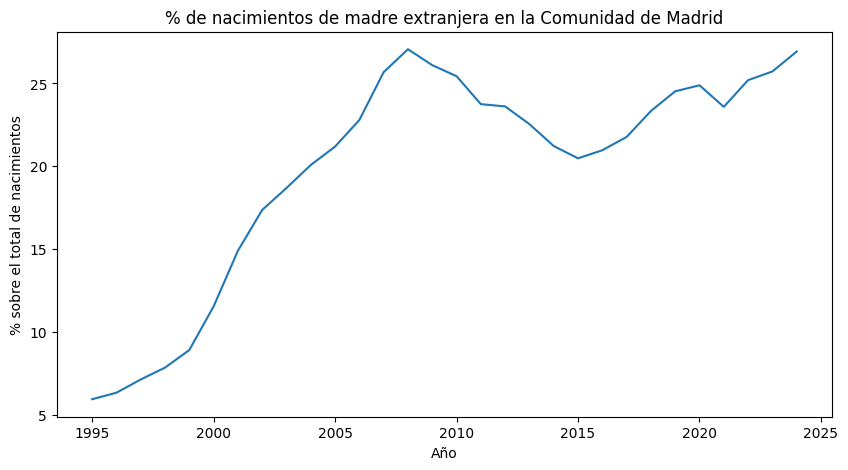

In [19]:
espanolas = df_nacionalidad[df_nacionalidad["Concepto"] == "Nacimientos de madres residentes españolas"][["Año", "Valor"]].rename(columns={"Valor": "españolas"})
extranjeras = df_nacionalidad[df_nacionalidad["Concepto"] == "Nacimientos de madres residentes extranjeras"][["Año", "Valor"]].rename(columns={"Valor": "extranjeras"})

evolucion = espanolas.merge(extranjeras, on="Año")
evolucion["total"] = evolucion["españolas"] + evolucion["extranjeras"]
evolucion["pct_extranjeras"] = evolucion["extranjeras"] / evolucion["total"] * 100

plt.figure(figsize=(10, 5))
sns.lineplot(data=evolucion, x="Año", y="pct_extranjeras")
plt.title("% de nacimientos de madre extranjera en la Comunidad de Madrid")
plt.xlabel("Año")
plt.ylabel("% sobre el total de nacimientos")
plt.show()

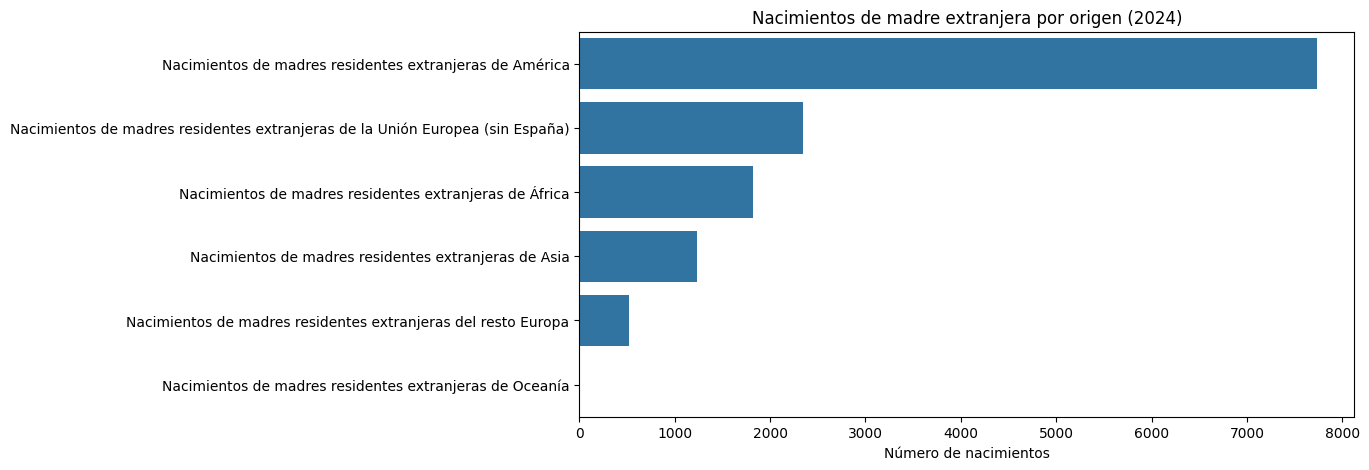

In [20]:
continentes = ["Nacimientos de madres residentes extranjeras de África",
               "Nacimientos de madres residentes extranjeras del resto Europa",
               "Nacimientos de madres residentes extranjeras de Asia",
               "Nacimientos de madres residentes extranjeras de América",
               "Nacimientos de madres residentes extranjeras de la Unión Europea (sin España)",
               "Nacimientos de madres residentes extranjeras de Oceanía"]

origen_2024 = df_nacionalidad[
    (df_nacionalidad["Año"] == 2024) &
    (df_nacionalidad["Concepto"].isin(continentes))
].sort_values("Valor", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=origen_2024, x="Valor", y="Concepto")
plt.title("Nacimientos de madre extranjera por origen (2024)")
plt.xlabel("Número de nacimientos")
plt.ylabel("")
plt.show()

## Conclusiones del EDA

- La natalidad en la Comunidad de Madrid ha caído de forma sostenida desde 2008: la tasa bruta pasó de 12,4‰ 
a 7,2‰ en 2024.
- La edad media de la madre ha subido de 28,6 a 33,7 años en el mismo periodo — la ayuda a la natalidad, dirigida a madres de hasta 30 años, apunta a un perfil cada vez más minoritario.
- Madrid capital concentra, con diferencia, el mayor número de nacimientos de madres jóvenes (≤29 años), seguida de municipios de la corona sur/este como Parla, Alcalá de Henares y Móstoles.
- El peso de los nacimientos de madre extranjera ha crecido del 5,9% (1995) al 26,9% (2024), con América como origen mayoritario.